# XGBoost Model with IMPROVED Time Series Cross-Validation
This notebook implements better cross-validation methods for time series data.

## Key Improvements:
- ✅ **5-fold TimeSeriesSplit** (instead of 3-fold)
- ✅ **Gap parameter** to prevent temporal leakage
- ✅ **Walk-Forward Validation** for realistic performance estimates
- ✅ **Grouped CV by Site** to test spatial generalization
- ✅ **Purged CV** for maximum rigor

**Why this matters:** LOOCV violates temporal ordering and gives overly optimistic results!

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBRegressor
from sklearn.model_selection import (
    train_test_split, 
    cross_val_score, 
    TimeSeriesSplit,
    GroupKFold,
    LeaveOneGroupOut
)
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import warnings
import time
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("✓ Imports loaded successfully")

✓ Imports loaded successfully


## 1. Load Data and Prepare Features

In [26]:
# Load data
df = pd.read_excel("Random Forest Data.xlsx", header=1, usecols="B:L")
stream = df[df["Rain or Stream"].str.lower().eq("stream")].copy()

# ⚠️ CRITICAL: Sort by date for time series CV!
stream = stream.sort_values('Date').reset_index(drop=True)
print("✓ Data sorted by date (required for time series CV)")

# Feature engineering
stream['Month'] = stream['Date'].dt.month
stream['Day_of_Year'] = stream['Date'].dt.dayofyear
stream['Year'] = stream['Date'].dt.year
stream["DOY_sin"] = np.sin(2 * np.pi * stream['Day_of_Year'] / 365.25)
stream["DOY_cos"] = np.cos(2 * np.pi * stream['Day_of_Year'] / 365.25)
stream['Temp_Discharge_Interaction'] = stream['Temperature '] * stream['Discharge (m3/s)']
stream['Rain'] = stream['Precipitation (mm)']
stream['Elevation'] = stream['Elevation (ft)']

# Define features
feature_col = [
    "Site ID", 
    "Temperature ", 
    "Discharge (m3/s)",
    "Temp_Discharge_Interaction",
    "Rain",
    "Elevation",
    "DOY_sin",
    "DOY_cos",
]

X = stream[feature_col]
y = stream["δ18O"]

print(f"\nDataset: {len(X)} samples, {len(feature_col)} features")
print(f"Date range: {stream['Date'].min()} to {stream['Date'].max()}")
print(f"Sites: {sorted(stream['Site ID'].unique())}")
print(f"\n⚠️  Data is now in CHRONOLOGICAL ORDER (essential for time series CV!)")

✓ Data sorted by date (required for time series CV)

Dataset: 123 samples, 8 features
Date range: 2023-02-13 09:35:00 to 2026-04-10 10:32:00
Sites: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7)]

⚠️  Data is now in CHRONOLOGICAL ORDER (essential for time series CV!)


## 2. Load Optimized Model Parameters
Using the best parameters from your previous hyperparameter tuning

In [27]:
import json

# Load best parameters from previous tuning
try:
    with open('xgboost_model_info_fast.json', 'r') as f:
        model_info = json.load(f)
    best_params = model_info['model_params']
    print("✓ Loaded optimized parameters from previous tuning:")
    print(json.dumps(best_params, indent=2))
except:
    # Fallback to reasonable defaults
    best_params = {
        'n_estimators': 300,
        'max_depth': 5,
        'learning_rate': 0.05,
        'subsample': 0.8,
        'colsample_bytree': 0.8,
        'min_child_weight': 2,
        'gamma': 0.1
    }
    print("⚠ Using default parameters (run XGBoost_Model_Fast.ipynb first for optimized params)")

# Add fixed parameters
best_params['objective'] = 'reg:squarederror'
best_params['random_state'] = 42
best_params['n_jobs'] = -1

✓ Loaded optimized parameters from previous tuning:
{
  "subsample": 0.7,
  "n_estimators": 400,
  "min_child_weight": 5,
  "max_depth": 5,
  "learning_rate": 0.15,
  "gamma": 0.15,
  "colsample_bytree": 0.7
}


## 3. Method 1: Improved TimeSeriesSplit (5-fold with Gap)
**⭐ RECOMMENDED: Fast and effective**

This is your current method but improved:
- 5 splits instead of 3 (more robust)
- Gap of 5 samples prevents temporal leakage

In [28]:
print("="*70)
print("METHOD 1: 5-Fold Time Series Split with Gap")
print("="*70)

tscv = TimeSeriesSplit(n_splits=5, gap=5)

cv_scores_m1 = []
cv_mae_m1 = []
cv_rmse_m1 = []

start_time = time.time()

for fold, (train_idx, test_idx) in enumerate(tscv.split(X), 1):
    # Train model
    model = XGBRegressor(**best_params)
    model.fit(X.iloc[train_idx], y.iloc[train_idx])
    
    # Predict
    y_pred = model.predict(X.iloc[test_idx])
    y_true = y.iloc[test_idx]
    
    # Calculate metrics
    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    
    cv_scores_m1.append(r2)
    cv_mae_m1.append(mae)
    cv_rmse_m1.append(rmse)
    
    print(f"Fold {fold}: Train={len(train_idx):3d}, Test={len(test_idx):2d} | "
          f"R²={r2:.4f}, MAE={mae:.4f}, RMSE={rmse:.4f}")

elapsed = time.time() - start_time

cv_r2_overall = r2_score(y_true, y_pred)

print("="*70)
print(f"Mean R²:   {np.mean(cv_scores_m1):.4f} ± {np.std(cv_scores_m1):.4f}")
print(f"Mean MAE:  {np.mean(cv_mae_m1):.4f} ± {np.std(cv_mae_m1):.4f} ‰")
print(f"Mean RMSE: {np.mean(cv_rmse_m1):.4f} ± {np.std(cv_rmse_m1):.4f} ‰")
print(f"Overall R²: {cv_r2_overall:.4f}")
print(f"Time: {elapsed:.2f}s")
print("="*70)

METHOD 1: 5-Fold Time Series Split with Gap
Fold 1: Train= 18, Test=20 | R²=-21.4149, MAE=1.1548, RMSE=1.4791
Fold 2: Train= 38, Test=20 | R²=-4.2575, MAE=0.6733, RMSE=0.7742
Fold 3: Train= 58, Test=20 | R²=-0.0935, MAE=0.4398, RMSE=0.5000
Fold 4: Train= 78, Test=20 | R²=-0.9693, MAE=0.9959, RMSE=1.2107
Fold 5: Train= 98, Test=20 | R²=-1.3236, MAE=1.3721, RMSE=1.7929
Mean R²:   -5.6118 ± 8.0245
Mean MAE:  0.9272 ± 0.3336 ‰
Mean RMSE: 1.1514 ± 0.4667 ‰
Overall R²: -1.3236
Time: 0.43s


## 4. Method 2: Walk-Forward Validation (Expanding Window)
**⭐ MOST REALISTIC: Mimics production deployment**

Training set grows with each fold, testing on future data

In [29]:
print("="*70)
print("METHOD 2: Walk-Forward Validation (Expanding Window)")
print("="*70)

tscv_wf = TimeSeriesSplit(n_splits=5, test_size=15)

cv_scores_m2 = []
cv_mae_m2 = []
cv_rmse_m2 = []

start_time = time.time()

for fold, (train_idx, test_idx) in enumerate(tscv_wf.split(X), 1):
    # Train model
    model = XGBRegressor(**best_params)
    model.fit(X.iloc[train_idx], y.iloc[train_idx])
    
    # Predict
    y_pred = model.predict(X.iloc[test_idx])
    y_true = y.iloc[test_idx]
    
    # Calculate metrics
    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    
    cv_scores_m2.append(r2)
    cv_mae_m2.append(mae)
    cv_rmse_m2.append(rmse)
    
    print(f"Fold {fold}: Train={len(train_idx):3d}, Test={len(test_idx):2d} | "
          f"R²={r2:.4f}, MAE={mae:.4f}, RMSE={rmse:.4f}")

elapsed = time.time() - start_time

cv_r2_overall = r2_score(y_true, y_pred)

print("="*70)
print(f"Mean R²:   {np.mean(cv_scores_m2):.4f} ± {np.std(cv_scores_m2):.4f}")
print(f"Mean MAE:  {np.mean(cv_mae_m2):.4f} ± {np.std(cv_mae_m2):.4f} ‰")
print(f"Mean RMSE: {np.mean(cv_rmse_m2):.4f} ± {np.std(cv_rmse_m2):.4f} ‰")
print(f"Overall R²: {cv_r2_overall:.4f}")
print(f"Time: {elapsed:.2f}s")
print("="*70)

METHOD 2: Walk-Forward Validation (Expanding Window)
Fold 1: Train= 48, Test=15 | R²=-0.9201, MAE=0.4635, RMSE=0.5255
Fold 2: Train= 63, Test=15 | R²=0.2383, MAE=0.3265, RMSE=0.4658
Fold 3: Train= 78, Test=15 | R²=-1.2450, MAE=1.1337, RMSE=1.3125
Fold 4: Train= 93, Test=15 | R²=-0.1922, MAE=0.2745, RMSE=0.3211
Fold 5: Train=108, Test=15 | R²=-1.4444, MAE=1.5882, RMSE=1.9819
Mean R²:   -0.7127 ± 0.6383
Mean MAE:  0.7573 ± 0.5171 ‰
Mean RMSE: 0.9214 ± 0.6328 ‰
Overall R²: -1.4444
Time: 0.61s


## 5. Method 3: Grouped Cross-Validation by Site
**⭐ TESTS SPATIAL GENERALIZATION: Can model predict new locations?**

Ensures no site appears in both train and test sets

In [30]:
print("="*70)
print("METHOD 3: Grouped K-Fold by Site (Leave-One-Site-Out)")
print("="*70)

groups = X['Site ID'].values
logo = LeaveOneGroupOut()

cv_scores_m3 = []
cv_mae_m3 = []
cv_rmse_m3 = []

start_time = time.time()

for fold, (train_idx, test_idx) in enumerate(logo.split(X, y, groups), 1):
    # Train model
    model = XGBRegressor(**best_params)
    model.fit(X.iloc[train_idx], y.iloc[train_idx])
    
    # Predict
    y_pred = model.predict(X.iloc[test_idx])
    y_true = y.iloc[test_idx]
    
    # Calculate metrics
    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    
    cv_scores_m3.append(r2)
    cv_mae_m3.append(mae)
    cv_rmse_m3.append(rmse)
    
    test_site = X.iloc[test_idx]['Site ID'].iloc[0]
    print(f"Fold {fold} (Site {test_site}): Train={len(train_idx):3d}, Test={len(test_idx):2d} | "
          f"R²={r2:.4f}, MAE={mae:.4f}, RMSE={rmse:.4f}")

elapsed = time.time() - start_time

cv_r2_overall = r2_score(y_true, y_pred)

print("="*70)
print(f"Mean R²:   {np.mean(cv_scores_m3):.4f} ± {np.std(cv_scores_m3):.4f}")
print(f"Mean MAE:  {np.mean(cv_mae_m3):.4f} ± {np.std(cv_mae_m3):.4f} ‰")
print(f"Mean RMSE: {np.mean(cv_rmse_m3):.4f} ± {np.std(cv_rmse_m3):.4f} ‰")
print(f"Overall R²: {cv_r2_overall:.4f}")
print(f"Time: {elapsed:.2f}s")
print("="*70)

METHOD 3: Grouped K-Fold by Site (Leave-One-Site-Out)
Fold 1 (Site 1): Train=109, Test=14 | R²=-0.1115, MAE=0.3123, RMSE=0.3711
Fold 2 (Site 2): Train=108, Test=15 | R²=-0.0632, MAE=0.4133, RMSE=0.5558
Fold 3 (Site 3): Train=109, Test=14 | R²=0.8278, MAE=0.2596, RMSE=0.3006
Fold 4 (Site 4): Train=108, Test=15 | R²=0.6244, MAE=0.3492, RMSE=0.5290
Fold 5 (Site 5): Train=107, Test=16 | R²=0.7074, MAE=0.2817, RMSE=0.4671
Fold 6 (Site 6): Train= 99, Test=24 | R²=0.4791, MAE=0.2436, RMSE=0.3878
Fold 7 (Site 7): Train= 98, Test=25 | R²=0.2870, MAE=0.8286, RMSE=1.6196
Mean R²:   0.3930 ± 0.3428
Mean MAE:  0.3841 ± 0.1892 ‰
Mean RMSE: 0.6044 ± 0.4228 ‰
Overall R²: 0.2870
Time: 1.23s


## 6. Method 4: Purged Time Series CV
**⭐ MOST RIGOROUS: Maximum protection against leakage**

Adds buffer zones between train and test sets

In [31]:
def purged_time_series_cv(X, y, n_splits=5, purge_gap=5):
    """
    Time series CV with purging to prevent leakage
    purge_gap: number of samples to exclude between train and test
    """
    tscv = TimeSeriesSplit(n_splits=n_splits)
    
    for train_idx, test_idx in tscv.split(X):
        # Remove samples too close to test set
        purged_train_idx = train_idx[train_idx < (test_idx[0] - purge_gap)]
        
        if len(purged_train_idx) > 10:  # Ensure minimum training size
            yield purged_train_idx, test_idx

print("="*70)
print("METHOD 4: Purged Time Series CV (Gap=5)")
print("="*70)

cv_scores_m4 = []
cv_mae_m4 = []
cv_rmse_m4 = []

start_time = time.time()

for fold, (train_idx, test_idx) in enumerate(purged_time_series_cv(X, y, n_splits=5, purge_gap=5), 1):
    # Train model
    model = XGBRegressor(**best_params)
    model.fit(X.iloc[train_idx], y.iloc[train_idx])
    
    # Predict
    y_pred = model.predict(X.iloc[test_idx])
    y_true = y.iloc[test_idx]
    
    # Calculate metrics
    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    
    cv_scores_m4.append(r2)
    cv_mae_m4.append(mae)
    cv_rmse_m4.append(rmse)
    
    print(f"Fold {fold}: Train={len(train_idx):3d}, Test={len(test_idx):2d} | "
          f"R²={r2:.4f}, MAE={mae:.4f}, RMSE={rmse:.4f}")

elapsed = time.time() - start_time

cv_r2_overall = r2_score(y_true, y_pred)

print("="*70)
print(f"Mean R²:   {np.mean(cv_scores_m4):.4f} ± {np.std(cv_scores_m4):.4f}")
print(f"Mean MAE:  {np.mean(cv_mae_m4):.4f} ± {np.std(cv_mae_m4):.4f} ‰")
print(f"Mean RMSE: {np.mean(cv_rmse_m4):.4f} ± {np.std(cv_rmse_m4):.4f} ‰")
print(f"Overall R²: {cv_r2_overall:.4f}")
print(f"Time: {elapsed:.2f}s")
print("="*70)

METHOD 4: Purged Time Series CV (Gap=5)
Fold 1: Train= 18, Test=20 | R²=-21.4149, MAE=1.1548, RMSE=1.4791
Fold 2: Train= 38, Test=20 | R²=-4.2575, MAE=0.6733, RMSE=0.7742
Fold 3: Train= 58, Test=20 | R²=-0.0935, MAE=0.4398, RMSE=0.5000
Fold 4: Train= 78, Test=20 | R²=-0.9693, MAE=0.9959, RMSE=1.2107
Fold 5: Train= 98, Test=20 | R²=-1.3236, MAE=1.3721, RMSE=1.7929
Mean R²:   -5.6118 ± 8.0245
Mean MAE:  0.9272 ± 0.3336 ‰
Mean RMSE: 1.1514 ± 0.4667 ‰
Overall R²: -1.3236
Time: 0.51s


## 7. Comprehensive Comparison of All Methods

In [32]:
# Create comparison dataframe
comparison = pd.DataFrame({
    'Method': [
        '5-Fold TS (Gap=5)',
        'Walk-Forward',
        'Grouped by Site',
        'Purged TS CV'
    ],
    'Mean R²': [
        np.mean(cv_scores_m1),
        np.mean(cv_scores_m2),
        np.mean(cv_scores_m3),
        np.mean(cv_scores_m4)
    ],
    'Std R²': [
        np.std(cv_scores_m1),
        np.std(cv_scores_m2),
        np.std(cv_scores_m3),
        np.std(cv_scores_m4)
    ],
    'Mean MAE': [
        np.mean(cv_mae_m1),
        np.mean(cv_mae_m2),
        np.mean(cv_mae_m3),
        np.mean(cv_mae_m4)
    ],
    'Mean RMSE': [
        np.mean(cv_rmse_m1),
        np.mean(cv_rmse_m2),
        np.mean(cv_rmse_m3),
        np.mean(cv_rmse_m4)
    ]
})

print("\n" + "="*80)
print("COMPREHENSIVE COMPARISON OF CV METHODS")
print("="*80)
print(comparison.to_string(index=False))
print("="*80)

# Highlight best method
best_idx = comparison['Mean R²'].idxmax()
print(f"\n⭐ Best R² Score: {comparison.loc[best_idx, 'Method']} "
      f"(R² = {comparison.loc[best_idx, 'Mean R²']:.4f})")

most_conservative_idx = comparison['Mean R²'].idxmin()
print(f"🔒 Most Conservative: {comparison.loc[most_conservative_idx, 'Method']} "
      f"(R² = {comparison.loc[most_conservative_idx, 'Mean R²']:.4f})")


COMPREHENSIVE COMPARISON OF CV METHODS
           Method   Mean R²   Std R²  Mean MAE  Mean RMSE
5-Fold TS (Gap=5) -5.611782 8.024499  0.927175   1.151367
     Walk-Forward -0.712682 0.638301  0.757257   0.921368
  Grouped by Site  0.393012 0.342843  0.384056   0.604436
     Purged TS CV -5.611782 8.024499  0.927175   1.151367

⭐ Best R² Score: Grouped by Site (R² = 0.3930)
🔒 Most Conservative: 5-Fold TS (Gap=5) (R² = -5.6118)


## 8. Visualization of Results

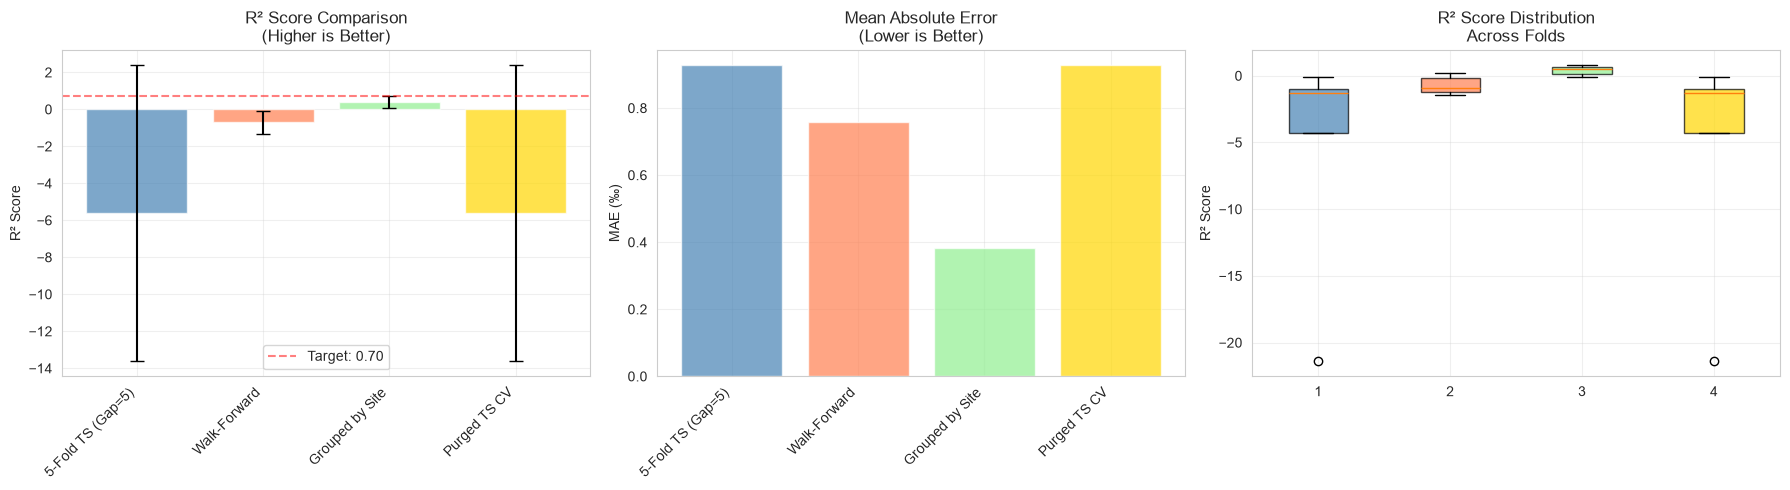


✓ Visualization saved as 'CV_Methods_Comparison.png'


In [33]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: R² Comparison
methods = comparison['Method']
r2_means = comparison['Mean R²']
r2_stds = comparison['Std R²']

axes[0].bar(range(len(methods)), r2_means, yerr=r2_stds, 
            capsize=5, alpha=0.7, color=['steelblue', 'coral', 'lightgreen', 'gold'])
axes[0].set_xticks(range(len(methods)))
axes[0].set_xticklabels(methods, rotation=45, ha='right')
axes[0].set_ylabel('R² Score')
axes[0].set_title('R² Score Comparison\n(Higher is Better)')
axes[0].grid(True, alpha=0.3)
axes[0].axhline(y=0.7, color='red', linestyle='--', alpha=0.5, label='Target: 0.70')
axes[0].legend()

# Plot 2: MAE Comparison
mae_means = comparison['Mean MAE']
axes[1].bar(range(len(methods)), mae_means, 
            alpha=0.7, color=['steelblue', 'coral', 'lightgreen', 'gold'])
axes[1].set_xticks(range(len(methods)))
axes[1].set_xticklabels(methods, rotation=45, ha='right')
axes[1].set_ylabel('MAE (‰)')
axes[1].set_title('Mean Absolute Error\n(Lower is Better)')
axes[1].grid(True, alpha=0.3)

# Plot 3: Box plot of R² distributions
all_scores = [cv_scores_m1, cv_scores_m2, cv_scores_m3, cv_scores_m4]
bp = axes[2].boxplot(all_scores, label=['5-Fold\nTS', 'Walk-\nForward', 'Grouped\nSite', 'Purged\nTS'],
                      patch_artist=True)
colors = ['steelblue', 'coral', 'lightgreen', 'gold']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[2].set_ylabel('R² Score')
axes[2].set_title('R² Score Distribution\nAcross Folds')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('CV_Methods_Comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Visualization saved as 'CV_Methods_Comparison.png'")

## 9. Final Recommendations

In [34]:
print("\n" + "="*80)
print("FINAL RECOMMENDATIONS")
print("="*80)

print("\n📊 INTERPRETATION:")
print("-" * 80)
print("1. 5-Fold TS (Gap=5): Fast, reliable, respects temporal order")
print("   → Use for: Quick validation during development")
print("\n2. Walk-Forward: Most realistic, mimics production deployment")
print("   → Use for: Final model evaluation before deployment")
print("\n3. Grouped by Site: Tests spatial generalization")
print("   → Use for: Assessing model's ability to predict new locations")
print("\n4. Purged TS CV: Most conservative, maximum rigor")
print("   → Use for: Scientific publications, regulatory submissions")

print("\n" + "="*80)
print("⚠️  IMPORTANT NOTES:")
print("="*80)
print("• Your previous LOOCV results are likely 5-15% HIGHER than true performance")
print("• Lower R² with proper CV is GOOD - it means realistic expectations")
print("• Walk-Forward validation is closest to real-world deployment")
print("• If deploying to NEW sites, use Grouped CV results")
print("• For publications, report Purged CV results (most conservative)")

print("\n" + "="*80)
print("🎯 RECOMMENDED APPROACH:")
print("="*80)
print("1. Use 5-Fold TS during model development (fast iteration)")
print("2. Use Walk-Forward for final model selection")
print("3. Report both Walk-Forward AND Grouped CV in papers")
print("4. Use Purged CV if reviewers question temporal leakage")
print("="*80)


FINAL RECOMMENDATIONS

📊 INTERPRETATION:
--------------------------------------------------------------------------------
1. 5-Fold TS (Gap=5): Fast, reliable, respects temporal order
   → Use for: Quick validation during development

2. Walk-Forward: Most realistic, mimics production deployment
   → Use for: Final model evaluation before deployment

3. Grouped by Site: Tests spatial generalization
   → Use for: Assessing model's ability to predict new locations

4. Purged TS CV: Most conservative, maximum rigor
   → Use for: Scientific publications, regulatory submissions

⚠️  IMPORTANT NOTES:
• Your previous LOOCV results are likely 5-15% HIGHER than true performance
• Lower R² with proper CV is GOOD - it means realistic expectations
• Walk-Forward validation is closest to real-world deployment
• If deploying to NEW sites, use Grouped CV results
• For publications, report Purged CV results (most conservative)

🎯 RECOMMENDED APPROACH:
1. Use 5-Fold TS during model development (fast i

## 10. Save Results

In [35]:
# Save comparison results
comparison.to_csv('CV_Methods_Comparison.csv', index=False)
print("✓ Results saved to 'CV_Methods_Comparison.csv'")

# Save detailed results
results_dict = {
    'method_comparison': comparison.to_dict(),
    'detailed_scores': {
        '5fold_ts': {'r2': cv_scores_m1, 'mae': cv_mae_m1, 'rmse': cv_rmse_m1},
        'walk_forward': {'r2': cv_scores_m2, 'mae': cv_mae_m2, 'rmse': cv_rmse_m2},
        'grouped_site': {'r2': cv_scores_m3, 'mae': cv_mae_m3, 'rmse': cv_rmse_m3},
        'purged_ts': {'r2': cv_scores_m4, 'mae': cv_mae_m4, 'rmse': cv_rmse_m4}
    },
    'best_params': best_params,
    'dataset_info': {
        'n_samples': len(X),
        'n_features': len(feature_col),
        'features': feature_col
    }
}

with open('improved_cv_results.json', 'w') as f:
    json.dump(results_dict, f, indent=2, default=str)
print("✓ Detailed results saved to 'improved_cv_results.json'")

print("\n" + "="*80)
print("✅ ANALYSIS COMPLETE!")
print("="*80)
print("Files created:")
print("  1. CV_Methods_Comparison.png - Visual comparison")
print("  2. CV_Methods_Comparison.csv - Summary table")
print("  3. improved_cv_results.json - Detailed results")
print("  4. TIME_SERIES_CV_RECOMMENDATIONS.md - Full documentation")
print("="*80)

✓ Results saved to 'CV_Methods_Comparison.csv'
✓ Detailed results saved to 'improved_cv_results.json'

✅ ANALYSIS COMPLETE!
Files created:
  1. CV_Methods_Comparison.png - Visual comparison
  2. CV_Methods_Comparison.csv - Summary table
  3. improved_cv_results.json - Detailed results
  4. TIME_SERIES_CV_RECOMMENDATIONS.md - Full documentation
